In [1]:
# notebook for vlam/vbet plots for all populations from s3m
# was made because neoscore.py scorer is too slow for these plots since makeddotgrids has 60 x 120 grids instead of 100 so lengthy.

In [23]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import NEOfaster as nf
import NEOMOD3 as nm3
import neoom as no
import S3Marray as sm
import S3M_fullversion as smfull
import neoonlyS3M as neo3m
import trojans as tjn
import tnos as tn
import importlib
from functools import reduce
importlib.reload(nm3)

<module 'NEOMOD3' from '/astro/users/ds2004/digest3/NEOMOD3.py'>

In [34]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

In [40]:
obstime_str="2025-09-23T00:00:00"
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 186.35, -5.0, 46.27, -19.0
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 359.9, -0.07, -0.188316, -0.08016
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 80.0, 20.0, 0.12, 0.22
# add mag here
mag = 20.0
#mag = 21.563
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0

l_hat, v_hat = no.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = no.get_earth_and_observer(obstime_str) 

In [41]:
# for the values in vlam/vbet plots 
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 10.0, 20.0, 0.12, 0.22
l_hat, v_hat = no.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = no.get_earth_and_observer(obstime_str) 
neo_score, a, e, i= no.compute_neomod3_weight(0.2, 3.0, l_hat, v_hat, obstime, rE, vE, r_obs, array4D, H_center, a_center, e_center, i_center)




print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)

neo_score: 0.064957
a: 1.4547289094311036
e: 0.31736085318504975
i: 2.1368116120813023


In [43]:
def comp_sum1():
    
    N_rate = 31           #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101 --> 1 min 40 s for 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6

    vlam_vals  = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    vlam_deg_day = 0.12
    vbeta_deg_day = 0.22
    

    
    
    K = np.zeros((len(vlam_vals), len(vbet_vals)), dtype=float)
    
    for i,vlam in enumerate(vlam_vals):
        for j,vbet in enumerate(vbet_vals):
            dra, ddec = no.ecliptic_rates_to_radec_rates(ra0_deg, dec0_deg, vlam, vbet)
            w_int = no.weight_marginalized_over_d_and_ddot(array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                           ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,obstime_str=obstime_str
                                                           )
            

            K[j, i] = w_int
            #print(w_int, dra, ddec)
        #break
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent

K, extent= comp_sum1()

/tmp/ipykernel_3165335/2393986843.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


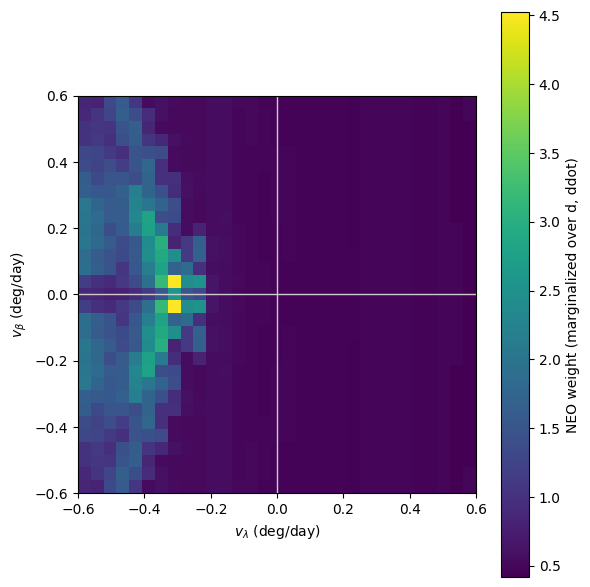

0.41915800000000003 0.495346 4.524813206899998


In [44]:
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(K, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEO weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.tight_layout()
plt.show()


print(np.min(K), np.median(K), np.max(K))

In [3]:
neo_s3m = neo3m.define_s3m()

['S0.s3m']
The final df is done.


In [4]:
neo_s3m

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,S0000001a,COM,1.251459,0.382244,9.304721,252.063850,185.610748,54067.969964,10.315,54466.0,1,6,-1,MOPS,2.025814
1,S0000002a,COM,1.286219,0.662518,18.303865,132.486568,80.463153,54670.088589,10.818,54466.0,1,6,-1,MOPS,3.811219
2,S0000003a,COM,0.617193,0.645272,10.302493,67.484378,182.131418,54522.349738,11.175,54466.0,1,6,-1,MOPS,1.739907
3,S0000004a,COM,0.383306,0.856419,16.988463,117.793282,242.430598,54973.510299,11.452,54466.0,1,6,-1,MOPS,2.669612
4,S0000005a,COM,0.569264,0.772125,22.761089,314.323204,73.119299,54075.567352,11.678,54466.0,1,6,-1,MOPS,2.498139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268506,S00019Npa,COM,1.120493,0.719870,7.215564,352.065443,22.728064,54356.369662,25.000,54466.0,1,6,-1,MOPS,3.999912
268507,S00019Nqa,COM,0.138585,0.904027,42.936671,97.053777,141.837873,54708.693935,25.000,54466.0,1,6,-1,MOPS,1.443995
268508,S00019Nra,COM,0.183840,0.741100,39.592137,226.887464,45.405407,54453.982901,25.000,54466.0,1,6,-1,MOPS,0.710082
268509,S00019Nsa,COM,1.005092,0.580448,11.451065,194.025698,170.089706,54067.389305,25.000,54466.0,1,6,-1,MOPS,2.395632


In [15]:
neo_s3m,array4D, H_center, a_center, e_center, i_center= neo3m.s3m_array(neo_s3m)

In [16]:
obstime_str="2025-09-23T00:00:00"
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 186.35, -5.0, 46.27, -19.0
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 359.9, -0.07, -0.188316, -0.08016
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 80.0, 20.0, 0.12, 0.22
# add mag here
mag = 20.0
#mag = 21.563
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0

l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 

In [17]:
# for the values in vlam/vbet plots 
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 10.0, 20.0, 0.12, 0.22
l_hat, v_hat = no.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = no.get_earth_and_observer(obstime_str) 
neo_score, a, e, i= no.compute_neomod3_weight(0.2, 3.0, l_hat, v_hat, obstime, rE, vE, r_obs, array4D, H_center, a_center, e_center, i_center)




print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)

neo_score: 1.0
a: 1.4547289094311036
e: 0.31736085318504975
i: 2.1368116120813023


In [21]:
def comp_sum1():
    
    N_rate = 31           #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101 --> 1 min 40 s for 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6

    vlam_vals  = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    vlam_deg_day = 0.12
    vbeta_deg_day = 0.22
    

    
    
    K = np.zeros((len(vlam_vals), len(vbet_vals)), dtype=float)
    
    for i,vlam in enumerate(vlam_vals):
        for j,vbet in enumerate(vbet_vals):
            dra, ddec = nf.ecliptic_rates_to_radec_rates(ra0_deg, dec0_deg, vlam, vbet)
            w_int = nf.weight_marginalized_over_d_and_ddot(array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                           ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,obstime_str=obstime_str
                                                           ,mag=mag)
            

            K[j, i] = w_int
            #print(w_int, dra, ddec)
        #break
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent

K, extent= comp_sum1()

/tmp/ipykernel_3165335/2393986843.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


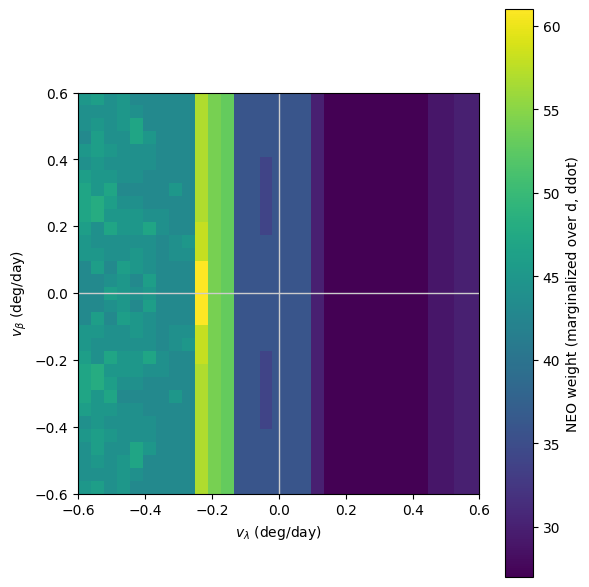

27.0 36.0 61.0


In [33]:
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(K, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEO weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.tight_layout()
plt.show()


print(np.min(K), np.median(K), np.max(K))

In [26]:
### trojans but idk if this is the right way to go abt this

In [27]:
trojans_s3m = tjn.define_s3m()

['St5.s3m']
The final df is done.


In [28]:
tjn_s3m,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = tjn.s3m_array(trojans_s3m)

In [29]:
obstime_str="2025-09-23T00:00:00"
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 186.35, -5.0, 46.27, -19.0
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 359.9, -0.07, -0.188316, -0.08016
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 80.0, 20.0, 0.12, 0.22
# add mag here
mag = 20.0
#mag = 21.563
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0

l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 

In [31]:
# for the values in vlam/vbet plots 
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 10.0, 20.0, 0.12, 0.22
l_hat, v_hat = no.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = no.get_earth_and_observer(obstime_str) 
neo_score, a, e, i= no.compute_neomod3_weight(0.2, 3.0, l_hat, v_hat, obstime, rE, vE, r_obs, array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn)




print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)

neo_score: 0.0
a: 1.4547289094311036
e: 0.31736085318504975
i: 2.1368116120813023


In [32]:
def comp_sum1():
    
    N_rate = 31           #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101 --> 1 min 40 s for 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6

    vlam_vals  = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    vlam_deg_day = 0.12
    vbeta_deg_day = 0.22
    

    
    
    K = np.zeros((len(vlam_vals), len(vbet_vals)), dtype=float)
    
    for i,vlam in enumerate(vlam_vals):
        for j,vbet in enumerate(vbet_vals):
            dra, ddec = nf.ecliptic_rates_to_radec_rates(ra0_deg, dec0_deg, vlam, vbet)
            w_int = nf.weight_marginalized_over_d_and_ddot(array4D=array4D_tjn, H_center=H_center_tjn, a_center=a_center_tjn, e_center=e_center_tjn, i_center=i_center_tjn,
                                                           ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,obstime_str=obstime_str
                                                           ,mag=mag)
            

            K[j, i] = w_int
            #print(w_int, dra, ddec)
        #break
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent

K, extent= comp_sum1()

KeyboardInterrupt: 

/tmp/ipykernel_3165335/1500458876.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


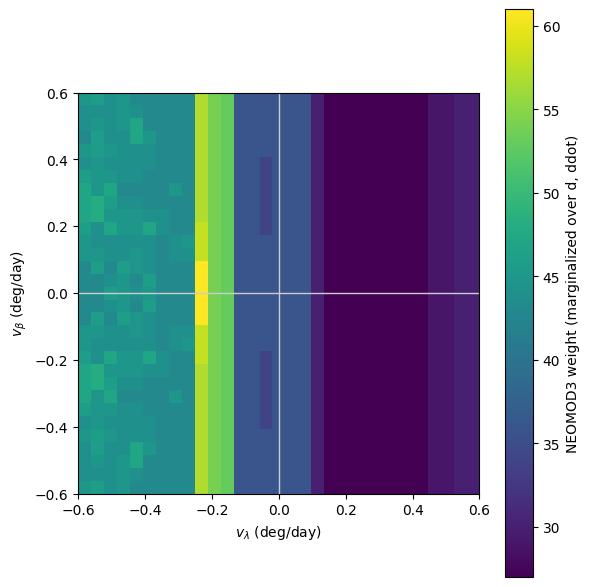

27.0 36.0 61.0


In [24]:
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(K, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.tight_layout()
plt.show()


print(np.min(K), np.median(K), np.max(K))